In [1]:
from admmcolinviz import ADMMColin
from matplotlib import pyplot as plt
import numpy as np

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Instantiate the ADMMColin object (the run history is saved in .h5 files in hierarchical format)
#### data directory structure : root/{alpha_value}/{dim}.h5

In [3]:
admmcolin = ADMMColin(alpha=0.01, dim=64, base_dir="run_data_admm_gurobi")

### trial(i) represents trial index for the randomized IP solver in the loop
### for randomized solver, there is a single trial : trial(0)

### The full JSON tree can be viewed using :

In [91]:
admmcolin.trial(0).series.compliance_disc[-1]

1.2895315678469232

In [56]:
c1 = admmcolin.trial(0).iters.control_1[19]
c2 = admmcolin.trial(0).iters.control_1[19]

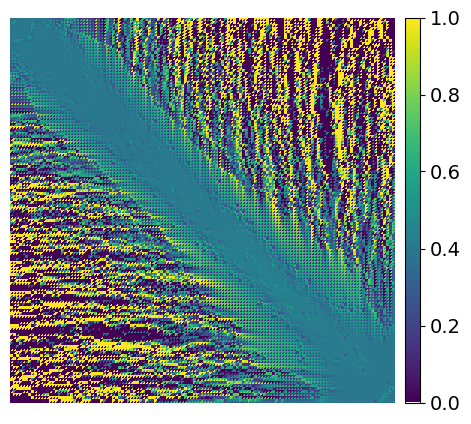

In [57]:
admmcolin.plot_control(c2)

Please enter a valid value for 'which' \in {1, 2}


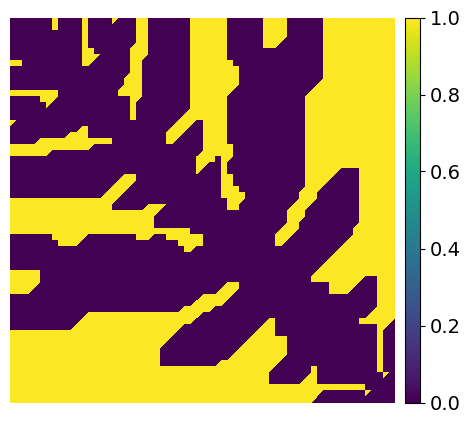

In [90]:
admmcolin.plot_control(disc=True)

In [24]:
import networkx as nx
import math

def build_graph(n_x: int, n_y: int):
    """Graph builder from the provided TV reference."""
    N = n_x * n_y
    graph = nx.Graph()
    graph.add_nodes_from(range(N))

    for k in range(0, N, 2):
        if k + 1 < N:
            graph.add_edge(k, k + 1)
        if (k + 2) % n_y != 0 and k + 3 < N:
            graph.add_edge(k, k + 3)
        if (k // n_y) != 0:
            nb = k - (n_y - 1)
            if nb >= 0:
                graph.add_edge(k, nb)

    return graph


def build_scale(graph: nx.Graph):
    scale = np.zeros(len(graph.edges()), dtype=float)
    for k, (u, v) in enumerate(graph.edges()):
        scale[k] = math.sqrt(2.0) if abs(int(u) - int(v)) == 1 else 1.0
    return scale


def compute_tv(control: np.ndarray, graph: nx.Graph, scale: np.ndarray) -> float:
    diffs = []
    for (u, v), s in zip(graph.edges(), scale):
        diffs.append(s * abs(control[u] - control[v]))
    return float(sum(diffs))


graph = build_graph(64, 2*64)
scale = build_scale(graph)
tv = compute_tv(admmcolin.trial(0).iters.control_disc[-1], graph, scale)
print(tv)

618.8772003600261


In [ ]:
print("total subproblem 1 runtime:",admmcolin.trial(0).series.runtime_sub1.sum())
print("total subproblem 2 runtime:",admmcolin.trial(0).series.runtime_sub2.sum())

total subproblem 1 runtime: 1.8436723269987851
total subproblem 2 runtime: 9.627769120037556


In [ ]:
admmcolin.trial(0).describe_tree()

### Here is an example on how to access the data in series group 

In [18]:
admmcolin.trial(0).series.objective_disc
#admmcolin.trial(0).series.infeas

array([11.60191742, 10.75944402, 11.12596075, 10.8487884 , 10.62099531,
        8.62109944,  8.56299446,  6.65752719,  4.3366999 ,  4.00007819,
        4.06634392,  4.07776485,  3.61896635,  3.43426848,  3.25956687,
        3.16072406,  3.13414339,  2.90033833,  2.63427518,  2.41724712])

### Here is an example on how to access the data in iters group (5th control and state iterate)

In [30]:
admmcolin.trial(0).series.tv_disc
#admmcolin.trial(0).series.infeas

array([139.65685425, 146.        , 154.        , 161.65685425,
       164.        , 171.65685425, 152.        , 167.3137085 ,
       159.65685425, 179.79898987, 186.14213562, 187.97056275,
       177.14213562, 185.11269837, 198.11269837, 188.79898987,
       192.79898987, 204.28427125, 210.79898987, 210.45584412])

In [59]:
control_2 = admmcolin.trial(0).iters.control_2[15]
control_1 = admmcolin.trial(0).iters.control_1[15]
control_disc = admmcolin.trial(0).iters.control_disc[15]
state_1 = admmcolin.trial(0).iters.state[15]

###  For randomized solver we store the median and best control, objective etc separately

In [ ]:
admmcolin.objective   #median
admmcolin.objective_best #best

## Same for control
admmcolin.control   #median
admmcolin.control_best #best

### Plot the best and median control across runs

Please enter a valid value for 'which' \in {1, 2}


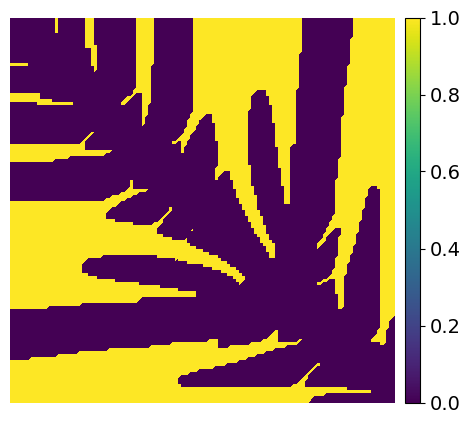

In [48]:
admmcolin.plot_control(disc=True) #median

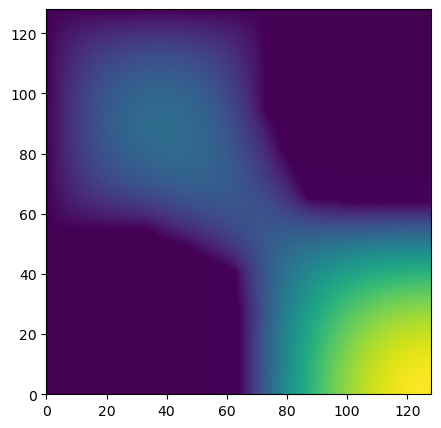

/home/harsh/topo_opt_git/admm_methods/admm_colin/admmcolinviz.py:162: UserWarning: Adding colorbar to a different Figure <Figure size 600x500 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, cax=cax, shrink=0.85)


<Figure size 640x480 with 0 Axes>

In [61]:
admmcolin.plot_state()

### To plot a specific iterate, you can pass it as an argument

In [ ]:
fig,ax = plt.subplots(figsize=(6,6), nrows=1, ncols=2)

c5 = admmcolin.trial(0).iters.control[5]
s5 = admmcolin.trial(0).iters.state[5]
admmcolin.plot_control(c5, ax=ax[0])
admmcolin.plot_state(s5, ax=ax[1])

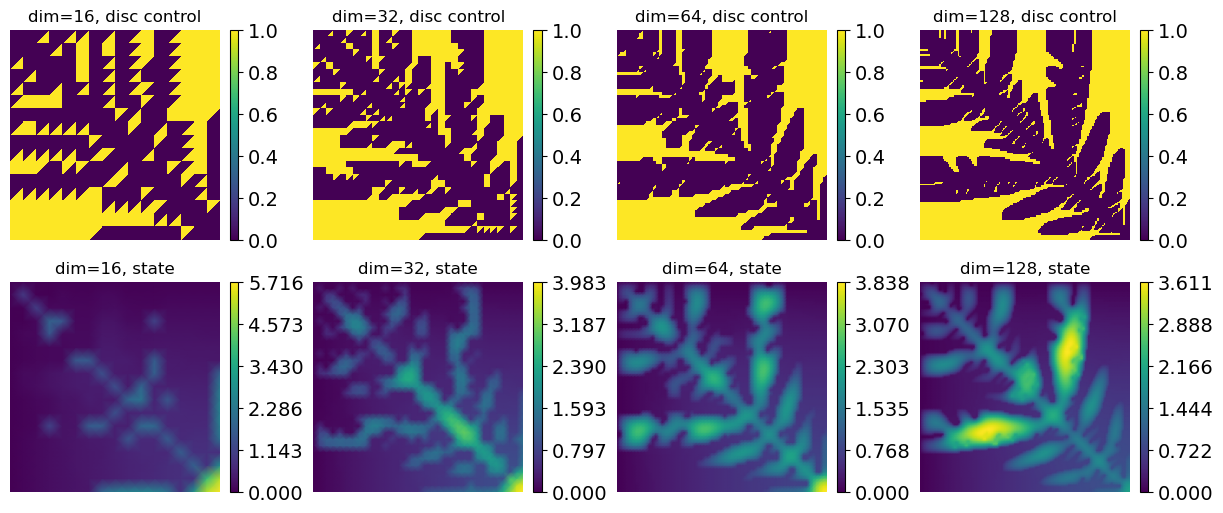

In [36]:
mesh_list = [16,32,64,128]
fig,ax = plt.subplots(figsize=(15,6), nrows=2, ncols=4)
for i, mesh in enumerate(mesh_list):
    admmcolin = ADMMColin(alpha=0.01, dim=mesh, base_dir="run_data_admm_running_avg_gurobi")
    c = admmcolin.trial(0).iters.control_disc[-1]
    s = admmcolin.trial(0).iters.state[-1]
    admmcolin.plot_control(c, ax=ax[0][i], show=False, title=f"dim={mesh}, disc control")
    admmcolin.plot_state(s, ax=ax[1][i], show=False, title=f"dim={mesh}, state")

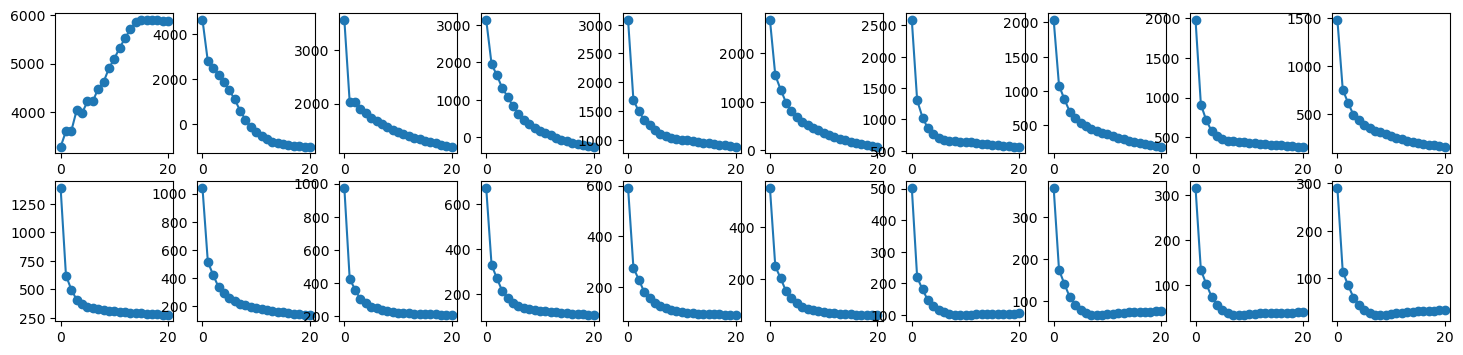

In [17]:
admmcolin = ADMMColin(alpha=0.01, dim=64, base_dir="run_data_admm_running_avg_gurobi")
fig,ax = plt.subplots(figsize=(18,4), nrows=2, ncols=10)

for i in range(20):
    f_i = admmcolin.trial(0).iters.oc_iters.F[i]
    ax[i//10][i%10].plot(f_i, label=f"iter {i}")
    ax[i//10][i%10].scatter(range(len(f_i)), f_i, label=f"iter {i}")

In [9]:
# Example calls (uncomment one):
#run_admm_animation(mesh_dim=32, folder="run_data_admm_running_avg_gurobi", alpha=0.01, seed=0)
run_admm_animation(mesh_dim=32, folder="run_data_admm_periodic_gurobi", alpha=0.01, seed=0)


Saved GIF: admm_anim_run_data_admm_periodic_gurobi_alpha_0.01_dim_32_seed_0.gif


'admm_anim_run_data_admm_periodic_gurobi_alpha_0.01_dim_32_seed_0.gif'

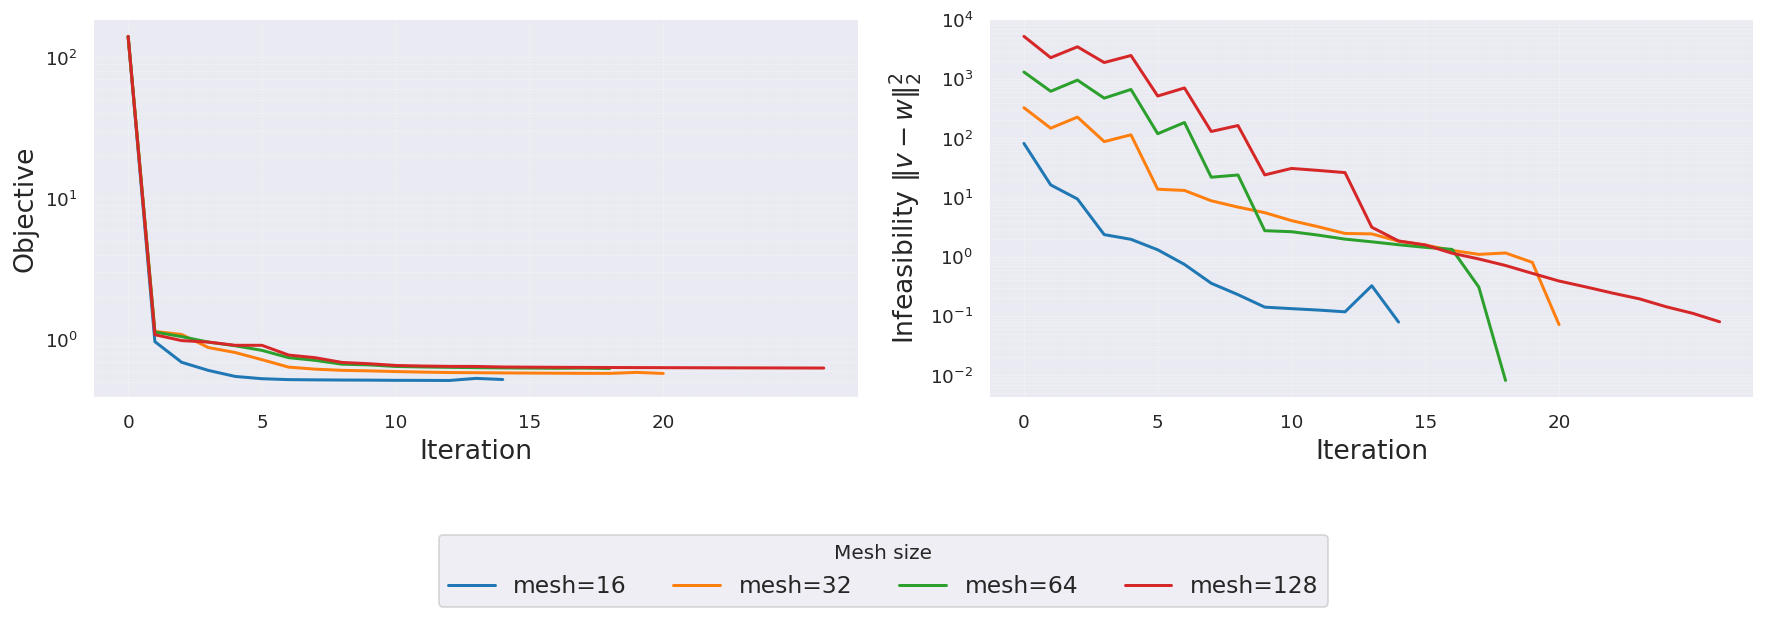

In [7]:
# Objective + infeasibility trajectories across mesh sizes (side-by-side)
mesh_sizes = [16, 32, 64, 128]
#base_dir = "run_data_admm_gurobi_great"
base_dir = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0

# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,
    "lines.linewidth": 2.8,
    "lines.markersize": 5,
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
colors = [cmap(i % cmap.N) for i in range(len(mesh_sizes))]


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for mesh, color in zip(mesh_sizes, colors):
    trial_series = ADMMColin(alpha=alpha, dim=mesh, base_dir=base_dir).trial(seed).series
    objective = np.asarray(trial_series.objective, dtype=float)
    infeas = np.asarray(trial_series.infeas, dtype=float)

    ax[0].plot(
        np.arange(len(objective)),
        objective,
        color=color,
        linewidth=1.8,
        label=f"mesh={mesh}",
        alpha=1.0,
    )

    ax[1].plot(
        np.arange(len(infeas)),
        infeas,
        color=color,
        linewidth=1.8,
        label=f"mesh={mesh}",
        alpha=1.0,
    )


# Objective plot
# ax[0].set_title("Objective Trajectories")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Objective")
ax[0].set_yscale("log")
ax[0].set_xticks([0, 5, 10, 15, 20])
ax[0].grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# Infeasibility plot
# ax[1].set_title("Infeasibility Trajectories")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel(r"Infeasibility $\|v-w\|_2^2$")
ax[1].set_yscale("log")
ax[1].set_xticks([0, 5, 10, 15, 20])
ax[1].grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)


# One shared legend below both plots
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Mesh size",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.1),
    ncol=len(mesh_sizes),
    frameon=True,
)

plt.tight_layout(rect=(0, 0.15, 1, 1))
plt.show()

In [7]:
admmcolin = ADMMColin(alpha=0.01, dim=128, base_dir="run_data_admm_running_avg_gurobi")
runtime1 = admmcolin.trial(0).series.runtime_sub1.sum()
runtime2 = admmcolin.trial(0).series.runtime_sub2.sum()
print(f"Total subproblem 1 runtime: {runtime1:.2f} seconds")
print(f"Total subproblem 2 runtime: {runtime2:.2f} seconds")
print(f"Total runtime: {runtime1 + runtime2:.2f} seconds")

Total subproblem 1 runtime: 314.24 seconds
Total subproblem 2 runtime: 2855.86 seconds
Total runtime: 3170.10 seconds


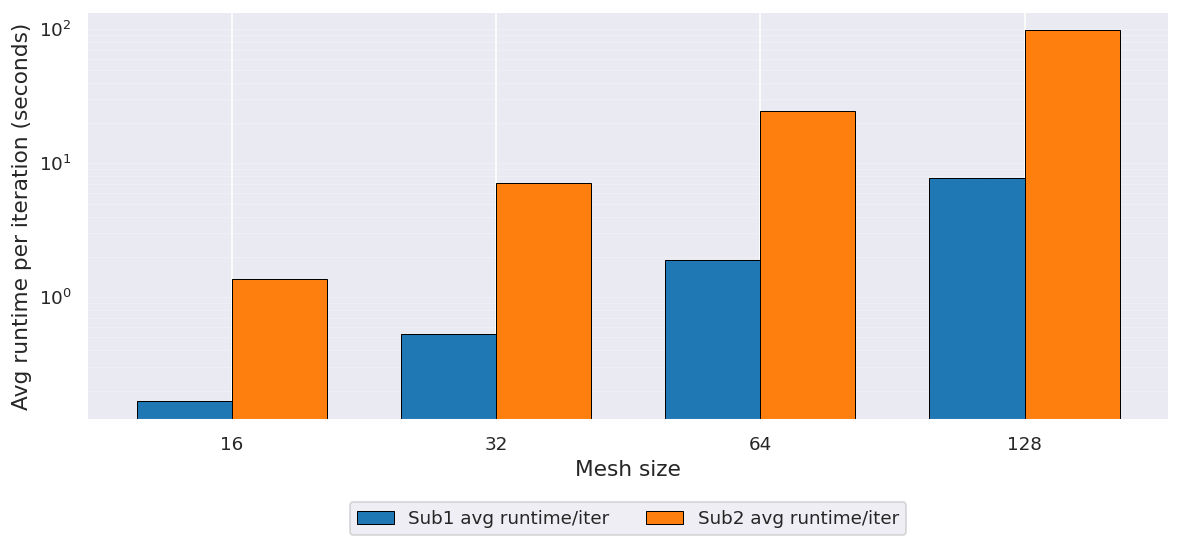

mesh= 16 | sub1=1.672e-01 s/iter | sub2=1.358e+00 s/iter
mesh= 32 | sub1=5.309e-01 s/iter | sub2=7.060e+00 s/iter
mesh= 64 | sub1=1.883e+00 s/iter | sub2=2.442e+01 s/iter
mesh=128 | sub1=7.720e+00 s/iter | sub2=9.798e+01 s/iter


In [8]:
# Runtime comparison across mesh sizes: average per-iteration subproblem runtime
mesh_sizes = [16, 32, 64, 128]
base_dir = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0

avg_sub1 = []
avg_sub2 = []

for mesh in mesh_sizes:
    trial_series = ADMMColin(alpha=alpha, dim=mesh, base_dir=base_dir).trial(seed).series
    runtime_sub1 = np.asarray(trial_series.runtime_sub1, dtype=float)
    runtime_sub2 = np.asarray(trial_series.runtime_sub2, dtype=float)

    avg_sub1.append(runtime_sub1.mean() if runtime_sub1.size > 0 else np.nan)
    avg_sub2.append(runtime_sub2.mean() if runtime_sub2.size > 0 else np.nan)


# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,
    "lines.linewidth": 2.8,
    "lines.markersize": 5,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(2)]


x = np.arange(len(mesh_sizes))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    avg_sub1,
    width=width,
    color=colors[0],
    edgecolor="black",
    linewidth=0.6,
    label="Sub1 avg runtime/iter",
)

ax.bar(
    x + width / 2,
    avg_sub2,
    width=width,
    color=colors[1],
    edgecolor="black",
    linewidth=0.6,
    label="Sub2 avg runtime/iter",
)

ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in mesh_sizes])
ax.set_xlabel("Mesh size")
ax.set_ylabel("Avg runtime per iteration (seconds)")
# ax.set_title("Per-Iteration Runtime by Mesh Size")

ax.set_yscale("log")

ax.grid(
    True,
    axis="y",
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# Legend below plot, same style as your second example
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


for mesh, r1, r2 in zip(mesh_sizes, avg_sub1, avg_sub2):
    print(f"mesh={mesh:>3} | sub1={r1:.3e} s/iter | sub2={r2:.3e} s/iter")

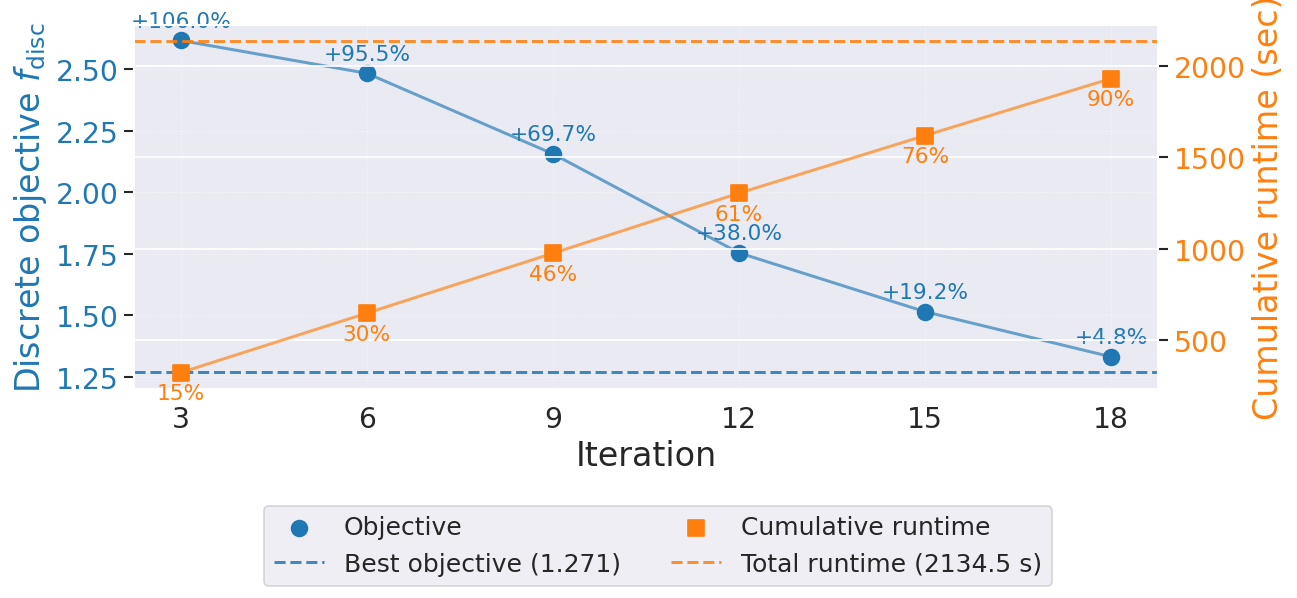

In [13]:
# Convergence vs. runtime tradeoff: objective_disc & cumulative runtime at every 3 iterations
dim = 128
objective_dir = "run_data_admm_gurobi_great"
runtime_dir   = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0
step = 3

# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,

    # line style
    "lines.linewidth": 2.8,
    "lines.markersize": 6,

    # global font sizes
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 15,
    "legend.title_fontsize": 16,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


trial_obj = ADMMColin(alpha=alpha, dim=dim, base_dir=objective_dir).trial(seed)
trial_rt  = ADMMColin(alpha=alpha, dim=dim, base_dir=runtime_dir).trial(seed)

obj_disc = np.asarray(trial_obj.series.objective_disc, dtype=float)
rt_sub1  = np.asarray(trial_rt.series.runtime_sub1, dtype=float)
rt_sub2  = np.asarray(trial_rt.series.runtime_sub2, dtype=float)

# cumulative total runtime at each completed iteration
n_iters_rt = min(len(rt_sub1), len(rt_sub2))
cum_runtime = np.cumsum(rt_sub1[:n_iters_rt] + rt_sub2[:n_iters_rt])

# align obj_disc: if it carries an extra initial entry at index 0, drop it
n_iters_obj = len(obj_disc)
if n_iters_obj == n_iters_rt + 1:
    obj_disc = obj_disc[1:]

n_iters = min(len(obj_disc), n_iters_rt)
obj_disc = obj_disc[:n_iters]
cum_runtime = cum_runtime[:n_iters]

# reference values for the dashed lines
max_runtime = cum_runtime[-1]
best_obj_disc = np.nanmin(obj_disc)

# select every step-th iteration
tick_iters = np.arange(step - 1, n_iters, step)

# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
color_obj = cmap(0)
color_rt = cmap(1)


fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

sc1 = ax1.scatter(
    tick_iters + 1,
    obj_disc[tick_iters],
    marker="o",
    s=90,
    color=color_obj,
    zorder=3,
    label="Objective",
)

ln1 = ax1.plot(
    tick_iters + 1,
    obj_disc[tick_iters],
    color=color_obj,
    linewidth=1.8,
    alpha=0.65,
    zorder=2,
)

sc2 = ax2.scatter(
    tick_iters + 1,
    cum_runtime[tick_iters],
    marker="s",
    s=90,
    color=color_rt,
    zorder=3,
    label="Cumulative runtime",
)

ln2 = ax2.plot(
    tick_iters + 1,
    cum_runtime[tick_iters],
    color=color_rt,
    linewidth=1.8,
    alpha=0.65,
    zorder=2,
)


# --- annotations ---
for idx in tick_iters:
    pct_obj = (obj_disc[idx] - best_obj_disc) / abs(best_obj_disc) * 100
    pct_rt = cum_runtime[idx] / max_runtime * 100

    ax1.annotate(
        f"+{pct_obj:.1f}%",
        xy=(idx + 1, obj_disc[idx]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=13,
        color=color_obj,
    )

    ax2.annotate(
        f"{pct_rt:.0f}%",
        xy=(idx + 1, cum_runtime[idx]),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        fontsize=13,
        color=color_rt,
    )


# --- reference dashed lines ---
hl_rt = ax2.axhline(
    max_runtime,
    color=color_rt,
    linewidth=1.8,
    linestyle="--",
    alpha=0.85,
    label=f"Total runtime ({max_runtime:.1f} s)",
)

hl_obj = ax1.axhline(
    best_obj_disc,
    color=color_obj,
    linewidth=1.8,
    linestyle="--",
    alpha=0.85,
    label=f"Best objective ({best_obj_disc:.4g})",
)


ax1.set_xlabel("Iteration")
ax1.set_ylabel(r"Discrete objective $f_{\rm disc}$", color=color_obj)
ax2.set_ylabel("Cumulative runtime (sec)", color=color_rt)

ax1.tick_params(axis="y", labelcolor=color_obj)
ax2.tick_params(axis="y", labelcolor=color_rt)

ax1.set_xticks(tick_iters + 1)
ax1.set_ylim(bottom=1.2)

ax1.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# Optional title; comment out if you want the clean paper-style look
# fig.suptitle(
#     f"Convergence vs. Runtime Tradeoff  |  dim={dim}, alpha={alpha}",
#     fontsize=20,
# )


handles = [sc1, hl_obj, sc2, hl_rt]
labels = [h.get_label() for h in handles]

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.15),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.13, 1, 1))
plt.show()

Loaded ADMM points: 30
Loaded OC points: 92
Using 72 non-overlapping bins of width 50.0 from 151.83 to 3761.55


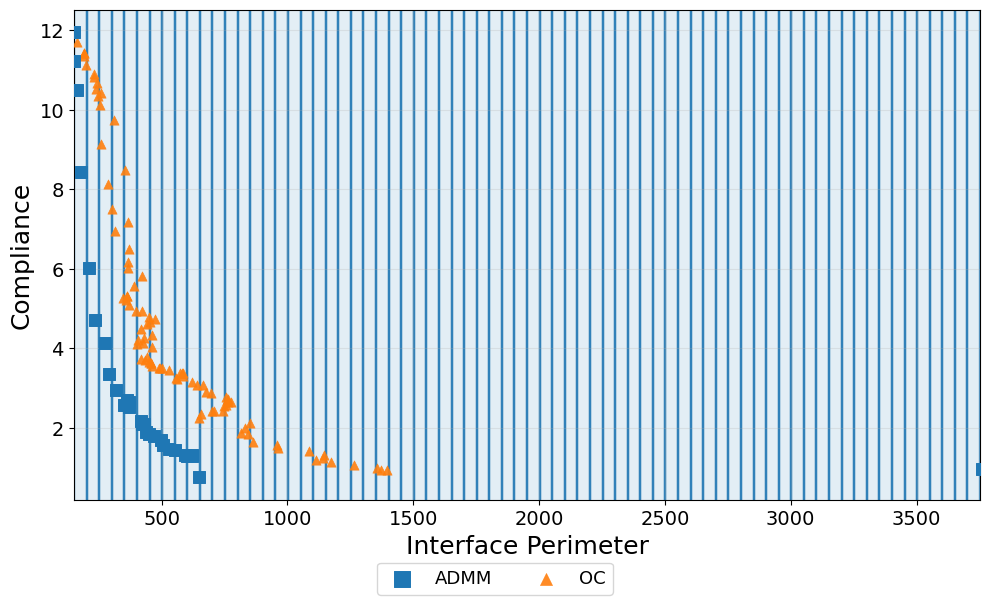

In [77]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py


def _safe_sorted_dirs(path):
    names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    try:
        return sorted(names, key=lambda x: float(x))
    except ValueError:
        return sorted(names)


def _last_value(x):
    arr = np.asarray(x, dtype=float)
    if arr.size == 0:
        raise ValueError("Empty dataset")
    return float(arr.reshape(-1)[-1])


# ----------------------------
# ADMM loader (via ADMMColin)
# ----------------------------
def load_admm_runs(base_dir="run_data_admm_gurobi"):
    rows = []

    for alpha_name in _safe_sorted_dirs(base_dir):
        alpha_path = os.path.join(base_dir, alpha_name)
        alpha = float(alpha_name)

        for fname in sorted(os.listdir(alpha_path)):
            if not fname.endswith(".h5"):
                continue

            dim = int(os.path.splitext(fname)[0])
            try:
                admm = ADMMColin(alpha=alpha, dim=dim, base_dir=base_dir)
                series = admm.trial(0).series

                compliance = _last_value(series.compliance_disc)
                perimeter = _last_value(series.tv_disc)

                rows.append(
                    {
                        "alpha": alpha,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "admm",
                        "path": os.path.join(alpha_path, fname),
                    }
                )
            except Exception as exc:
                print(f"Skipped ADMM file {os.path.join(alpha_path, fname)}: {exc}")

    return pd.DataFrame(rows)


# ---------------------------------------
# OC loader (direct root-dataset reading)
# ---------------------------------------
def load_oc_runs(base_dir="OC_results"):
    rows = []

    for r_name in _safe_sorted_dirs(base_dir):
        r_path = os.path.join(base_dir, r_name)
        r_val = float(r_name)

        for fname in sorted(os.listdir(r_path)):
            if not fname.endswith(".h5"):
                continue

            h5_path = os.path.join(r_path, fname)
            dim = int(os.path.splitext(fname)[0])

            try:
                with h5py.File(h5_path, "r") as f:
                    perimeter = _last_value(f["tv_disc"])
                    compliance = _last_value(f["compliance_disc"])

                rows.append(
                    {
                        "r": r_val,
                        "dim": dim,
                        "perimeter": perimeter,
                        "compliance": compliance,
                        "source": "oc",
                        "path": h5_path,
                    }
                )
            except Exception as exc:
                print(f"Skipped OC file {h5_path}: {exc}")

    return pd.DataFrame(rows)


admm_df = load_admm_runs(base_dir="run_data_admm_gurobi")
oc_df = load_oc_runs(base_dir="OC_results")

print(f"Loaded ADMM points: {len(admm_df)}")
print(f"Loaded OC points: {len(oc_df)}")

if admm_df.empty:
    print("ADMM dataframe is empty. Check run_data_admm_gurobi.")
elif oc_df.empty:
    print("OC dataframe is empty. Check OC_results.")
else:
    # Build non-overlapping bins of width 50, starting from the ADMM minimum perimeter.
    admm_perimeter_min = float(admm_df["perimeter"].min())
    admm_perimeter_max = float(admm_df["perimeter"].max())

    bin_width = 50.0
    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width

    # Drop the last bin if it would extend past the ADMM max perimeter.
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)

    centers = 0.5 * (bin_starts + bin_ends)

    print(
        f"Using {len(centers)} non-overlapping bins of width {bin_width:.1f} "
        f"from {admm_perimeter_min:.2f} to {admm_perimeter_max:.2f}"
    )

    BIN_COLOR = "tab:blue"
    BIN_FILL_ALPHA = 0.12
    BIN_EDGE_ALPHA = 0.70

    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Clearly visible bins: filled rectangles and solid boundaries in the same color.
    for left_edge, right_edge in zip(bin_starts, bin_ends):
        ax.axvspan(left_edge, right_edge, color=BIN_COLOR, alpha=BIN_FILL_ALPHA, zorder=0, linewidth=0)
        ax.axvline(left_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)
        ax.axvline(right_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)

    sc1 = ax.scatter(
        admm_df["perimeter"],
        admm_df["compliance"],
        marker="s",
        s=70,
        color=BIN_COLOR,
        #edgecolors="black",
        linewidth=0.7,
        label="ADMM",
        zorder=4,
    )

    sc2 = ax.scatter(
        oc_df["perimeter"],
        oc_df["compliance"],
        marker="^",
        s=45,
        color="tab:orange",
        #edgecolors="black",
        linewidth=0.4,
        alpha=0.9,
        label="OC",
        zorder=3,
    )

    # Bin count annotations just above the plot area.
    y_top = max(admm_df["compliance"].max(), oc_df["compliance"].max())
    y_bot = min(admm_df["compliance"].min(), oc_df["compliance"].min())
    y_text = y_top + 0.02 * (y_top - y_bot)

    for c, left_edge, right_edge in zip(centers, bin_starts, bin_ends):
        in_bin = (oc_df["perimeter"] >= left_edge) & (oc_df["perimeter"] < right_edge)
        n = int(in_bin.sum())
        # ax.text(c, y_text, str(n), ha="center", va="bottom", fontsize=8, color=BIN_COLOR, alpha=0.85)

    ax.set_xlabel("Interface Perimeter", fontsize=18)
    ax.set_ylabel("Compliance", fontsize=18)
    ax.set_xlim(admm_perimeter_min, bin_ends[-1])
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.tick_params(axis="both", which="minor", labelsize=12)
    # ax.set_title("Compliance vs Perimeter: ADMM bins with OC points")
    ax.grid(True, alpha=0.25)

    # Use actual scatter handles so legend marker shapes/colors are correct.
    handles = [sc1, sc2]
    labels = [h.get_label() for h in handles]
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.14),
        ncol=2,
        frameon=True,
        fontsize=13,
        markerscale=1.3,
    )

    plt.tight_layout(rect=(0, 0.11, 1, 1))
    plt.show()

    df_admm = admm_df.copy()
    df_oc = oc_df.copy()

In [74]:
admm_df

,alpha,dim,perimeter,compliance,source,path
0,0.01000,256,3761.551657,0.974104,admm,run_data_admm_gurobi/0.01/256.h5
1,0.01000,32,648.173665,0.753312,admm,run_data_admm_gurobi/0.01/32.h5
2,0.01000,64,618.877200,1.289532,admm,run_data_admm_gurobi/0.01/64.h5
3,0.01001,64,593.622366,1.310275,admm,run_data_admm_gurobi/0.01001/64.h5
4,0.01010,64,599.421356,1.298646,admm,run_data_admm_gurobi/0.0101/64.h5
5,0.01050,64,619.078210,1.305647,admm,run_data_admm_gurobi/0.0105/64.h5
6,0.01100,64,551.480231,1.454728,admm,run_data_admm_gurobi/0.011/64.h5
7,0.01200,64,527.823376,1.475826,admm,run_data_admm_gurobi/0.012/64.h5
8,0.01300,64,506.651804,1.580650,admm,run_data_admm_gurobi/0.013/64.h5
9,0.01320,64,498.166522,1.706671,admm,run_data_admm_gurobi/0.0132/64.h5


In [78]:
import os
import numpy as np

base_dir = "run_data_admm_gurobi"
folder_names = []
compliance_disc_list = []
tv_disc_list = []

for alpha_name in sorted(
    [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))],
    key=lambda x: float(x),
):
    alpha_path = os.path.join(base_dir, alpha_name)

    for fname in sorted(os.listdir(alpha_path)):
        if not fname.endswith(".h5"):
            continue

        dim = int(os.path.splitext(fname)[0])
        admmcolin = ADMMColin(alpha=float(alpha_name), dim=dim, base_dir=base_dir)
        series = admmcolin.trial(0).series

        folder_names.append(alpha_name)
        compliance_disc_list.append(float(np.asarray(series.compliance_disc, dtype=float)[-1]))
        tv_disc_list.append(float(np.asarray(series.tv_disc, dtype=float)[-1]))

print(folder_names)
print(compliance_disc_list)
print(tv_disc_list)

['0.01', '0.01', '0.01', '0.01001', '0.0101', '0.0105', '0.011', '0.012', '0.013', '0.0132', '0.0133', '0.0134', '0.014', '0.015', '0.017', '0.0175', '0.018', '0.0182', '0.0186', '0.019', '0.0194', '0.02', '0.04', '0.06', '0.08', '0.1', '0.12', '0.14', '0.16', '0.18']
[0.9741044456386889, 0.7533122541575373, 1.2895315678469232, 1.3102754241959824, 1.2986458808143793, 1.3056472942561532, 1.454728311782997, 1.475825916517742, 1.5806495682651454, 1.706670894003379, 1.7910450268746598, 1.8566295795808267, 1.9042891282722265, 2.099690892339636, 2.167506853554066, 2.0877573343184603, 2.588212185686661, 2.7094311152868302, 2.652743618853851, 2.941661367463409, 2.531212331935549, 2.584188451202788, 3.356227194011232, 4.140752756714196, 4.714712490276676, 6.0211103795631455, 8.43036415036869, 10.502553614024212, 11.212258810979419, 11.95348902057107]
[3761.55165748965, 648.1736649163083, 618.8772003600261, 593.6223663640869, 599.4213562373103, 619.0782104868026, 551.4802307403558, 527.823376490

In [64]:
np.where((np.array(tv_disc_list) > 450) & (np.array(tv_disc_list) < 500))

(array([], dtype=int64),)

In [79]:
import os
import h5py
import numpy as np

base_dir = "OC_results"
folder_names = []
compliance_disc_list = []
tv_disc_list = []

for r_name in sorted(
    [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))],
    key=lambda x: float(x),
):
    r_path = os.path.join(base_dir, r_name)

    for fname in sorted(os.listdir(r_path)):
        if not fname.endswith(".h5"):
            continue

        h5_path = os.path.join(r_path, fname)
        with h5py.File(h5_path, "r") as f:
            folder_names.append(r_name)
            compliance_disc_list.append(float(np.asarray(f["compliance_disc"], dtype=float)))
            tv_disc_list.append(float(np.asarray(f["tv_disc"], dtype=float)))

print(folder_names)
print(compliance_disc_list)
print(tv_disc_list)

['2.000000', '2.163265', '2.326531', '2.489796', '2.653061', '2.816327', '2.979592', '3.142857', '3.306122', '3.469388', '3.632653', '3.795918', '3.959184', '4.122449', '4.285714', '4.448980', '4.612245', '4.775510', '4.938776', '5.000000', '5.102041', '5.222222', '5.265306', '5.428571', '5.444444', '5.591837', '5.666667', '5.755102', '5.888889', '5.918367', '6.081633', '6.111111', '6.244898', '6.333333', '6.408163', '6.500000', '6.555556', '6.562500', '6.571429', '6.625000', '6.687500', '6.734694', '6.750000', '6.777778', '6.875000', '6.897959', '7.000000', '7.061224', '7.125000', '7.224490', '7.387755', '7.551020', '7.714286', '7.877551', '8.040816', '8.204082', '8.367347', '8.530612', '8.693878', '8.857143', '9.020408', '9.183673', '9.346939', '9.510204', '9.673469', '9.836735', '10.000000', '10.020000', '10.545263', '11.070526', '11.595789', '12.121053', '12.646316', '13.171579', '13.696842', '14.222105', '14.747368', '15.272632', '15.797895', '16.323158', '16.500000', '16.700000',

In [175]:
np.where((np.array(tv_disc_list) > 500) & (np.array(tv_disc_list) < 550))

(array([39, 40]),)

In [179]:
folder_names[39]

'6.625000'

In [181]:
folder_names[40]

'6.687500'

In [146]:
tv_disc_list[77]

310.2253967444164

In [80]:
import numpy as np
import pandas as pd

max_points_per_bin = 6
seed = 0

# Reuse existing bins if available; otherwise rebuild from ADMM perimeter range.
if "bin_starts" not in globals() or "bin_ends" not in globals():
    if "admm_df" not in globals() or admm_df.empty:
        raise ValueError("admm_df is not available. Run the ADMM/OC loading cell first.")

    admm_perimeter_min = float(admm_df["perimeter"].min())
    admm_perimeter_max = float(admm_df["perimeter"].max())
    bin_width = 50.0

    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)


def cap_points_per_bin(df, bin_starts, bin_ends, max_points=6, seed=0):
    if df.empty:
        return df.copy()

    rng = np.random.default_rng(seed)
    capped_parts = []

    for left_edge, right_edge in zip(bin_starts, bin_ends):
        in_bin = df[(df["perimeter"] >= left_edge) & (df["perimeter"] < right_edge)]

        if len(in_bin) > max_points:
            keep_idx = rng.choice(in_bin.index.to_numpy(), size=max_points, replace=False)
            in_bin = in_bin.loc[np.sort(keep_idx)]

        capped_parts.append(in_bin)

    if not capped_parts:
        return df.iloc[0:0].copy()

    capped_df = pd.concat(capped_parts, axis=0)
    return capped_df.reset_index(drop=True)


if "admm_df" not in globals() or "oc_df" not in globals():
    raise ValueError("admm_df or oc_df missing. Run the plotting/data loading cell first.")

admm_df_capped = cap_points_per_bin(admm_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed)
oc_df_capped = cap_points_per_bin(oc_df, bin_starts, bin_ends, max_points=max_points_per_bin, seed=seed + 1)

# Verification: each bin should have <= max_points_per_bin for both methods.
admm_bin_counts = []
oc_bin_counts = []

for left_edge, right_edge in zip(bin_starts, bin_ends):
    admm_count = int(((admm_df_capped["perimeter"] >= left_edge) & (admm_df_capped["perimeter"] < right_edge)).sum())
    oc_count = int(((oc_df_capped["perimeter"] >= left_edge) & (oc_df_capped["perimeter"] < right_edge)).sum())
    admm_bin_counts.append(admm_count)
    oc_bin_counts.append(oc_count)

print("ADMM counts per bin (capped):", admm_bin_counts)
print("OC counts per bin (capped):", oc_bin_counts)
print("ADMM max count:", max(admm_bin_counts) if admm_bin_counts else 0)
print("OC max count:", max(oc_bin_counts) if oc_bin_counts else 0)
print("Total ADMM points after cap:", len(admm_df_capped))
print("Total OC points after cap:", len(oc_df_capped))

ADMM counts per bin (capped): [4, 2, 2, 1, 5, 5, 2, 3, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
OC counts per bin (capped): [5, 5, 5, 3, 6, 6, 6, 2, 6, 3, 5, 3, 6, 4, 1, 0, 2, 0, 1, 3, 1, 0, 1, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ADMM max count: 5
OC max count: 6
Total ADMM points after cap: 29
Total OC points after cap: 77


Using 9 non-overlapping bins of width 50.0 from 151.83 to 648.17


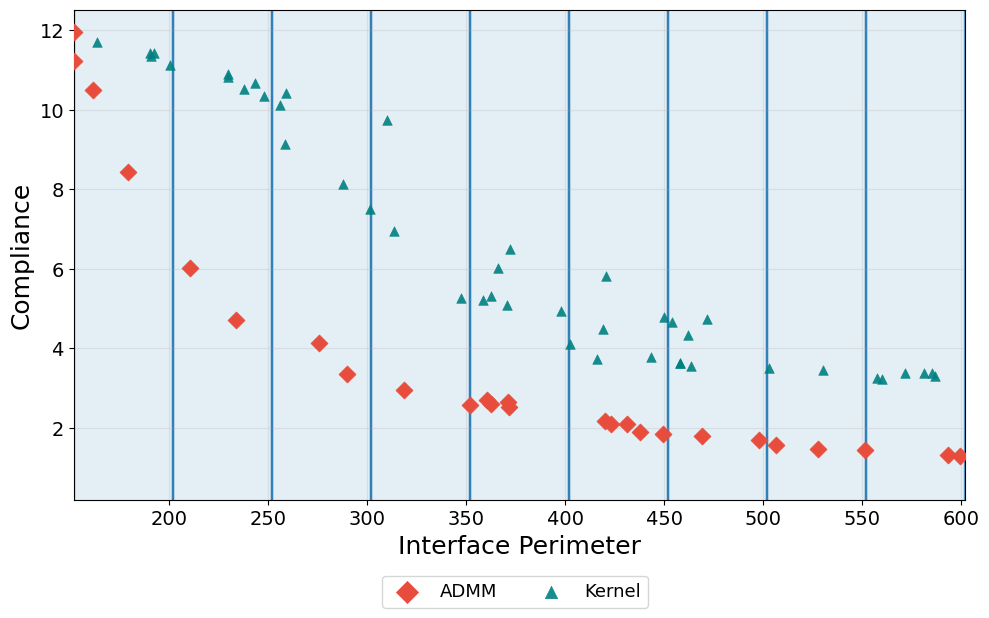

In [82]:
if admm_df_capped.empty:
    print("ADMM dataframe is empty. Check run_data_admm_gurobi.")
elif oc_df_capped.empty:
    print("OC dataframe is empty. Check OC_results.")
else:
    # Build non-overlapping bins of width 50, starting from the ADMM minimum perimeter.
    admm_perimeter_min = float(admm_df_capped["perimeter"].min())
    admm_perimeter_max = float(admm_df_capped["perimeter"].max())

    bin_width = 50.0
    bin_starts = np.arange(admm_perimeter_min, admm_perimeter_max, bin_width)
    bin_ends = bin_starts + bin_width

    # Drop the last bin if it would extend past the ADMM max perimeter.
    valid = bin_ends <= admm_perimeter_max
    bin_starts = bin_starts[valid]
    bin_ends = bin_ends[valid]

    if bin_starts.size == 0:
        bin_starts = np.array([admm_perimeter_min], dtype=float)
        bin_ends = np.array([admm_perimeter_min + bin_width], dtype=float)

    centers = 0.5 * (bin_starts + bin_ends)

    print(
        f"Using {len(centers)} non-overlapping bins of width {bin_width:.1f} "
        f"from {admm_perimeter_min:.2f} to {admm_perimeter_max:.2f}"
    )

    BIN_COLOR = "tab:blue"
    BIN_FILL_ALPHA = 0.12
    BIN_EDGE_ALPHA = 0.70

    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Clearly visible bins: filled rectangles and solid boundaries in the same color.
    for left_edge, right_edge in zip(bin_starts, bin_ends):
        ax.axvspan(left_edge, right_edge, color=BIN_COLOR, alpha=BIN_FILL_ALPHA, zorder=0, linewidth=0)
        ax.axvline(left_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)
        ax.axvline(right_edge, color=BIN_COLOR, linewidth=1.7, alpha=BIN_EDGE_ALPHA, zorder=1)

    # ADMM: red diamonds
    sc1 = ax.scatter(
        admm_df_capped["perimeter"],
        admm_df_capped["compliance"],
        marker="D",
        s=75,
        color="#e74c3c",
        #edgecolors="black",
        linewidth=0.5,
        label="ADMM",
        zorder=4,
    )

    # Kernel/OC: teal markers
    sc2 = ax.scatter(
        oc_df_capped["perimeter"],
        oc_df_capped["compliance"],
        marker="^",
        s=48,
        color="teal",
        #edgecolors="black",
        linewidth=0.4,
        alpha=0.9,
        label="Kernel",
        zorder=3,
    )

    # Bin count annotations just above the plot area.
    y_top = max(admm_df_capped["compliance"].max(), oc_df_capped["compliance"].max())
    y_bot = min(admm_df_capped["compliance"].min(), oc_df_capped["compliance"].min())
    y_text = y_top + 0.02 * (y_top - y_bot)

    for c, left_edge, right_edge in zip(centers, bin_starts, bin_ends):
        in_bin = (oc_df_capped["perimeter"] >= left_edge) & (oc_df_capped["perimeter"] < right_edge)
        n = int(in_bin.sum())
        # ax.text(c, y_text, str(n), ha="center", va="bottom", fontsize=8, color=BIN_COLOR, alpha=0.85)

    # Neutral labels and ticks (no color coding)
    ax.set_xlabel("Interface Perimeter", fontsize=18)
    ax.set_ylabel("Compliance", fontsize=18)
    ax.set_xlim(admm_perimeter_min, bin_ends[-1])
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.tick_params(axis="both", which="minor", labelsize=12)
    ax.grid(True, alpha=0.25)

    # Use actual scatter handles so legend marker shapes/colors are correct.
    handles = [sc1, sc2]
    labels = [h.get_label() for h in handles]
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.52, 0.12),
        ncol=2,
        frameon=True,
        fontsize=13,
        markerscale=1.3,
    )

    plt.tight_layout(rect=(0, 0.11, 1, 1))
    plt.show()

    df_admm = admm_df_capped.copy()
    df_oc = oc_df_capped.copy()

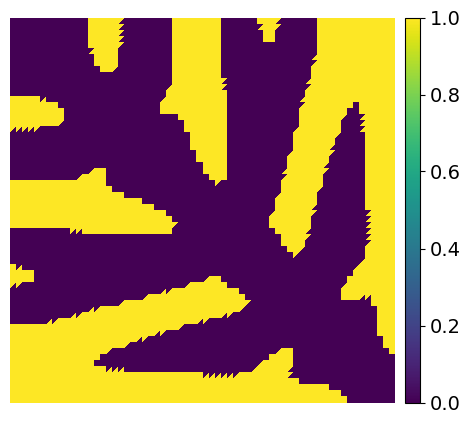

In [97]:
admmcolin.plot_control(control_disc, fix_diagonal_reflection=True)